In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- FUNCIÓN PARA ENCONTRAR ARCHIVOS ---
def buscar_archivo(nombre):
    posibles_rutas = [nombre, os.path.join('csv', nombre)]
    for ruta in posibles_rutas:
        if os.path.exists(ruta):
            return ruta
    return None

# Diccionario de Regiones con NOMBRES CORTOS para que se lean bien
dict_regiones = {
    15: 'Arica y Parinacota', 1: 'Tarapacá', 2: 'Antofagasta', 3: 'Atacama',
    4: 'Coquimbo', 5: 'Valparaíso', 13: 'Metropolitana', 6: 'O\'Higgins',
    7: 'Maule', 16: 'Ñuble', 8: 'Biobío', 9: 'Araucanía',
    14: 'Los Ríos', 10: 'Los Lagos', 11: 'Aysén', 12: 'Magallanes'
}

dict_dependencia = {1: 'Particular Pagado', 2: 'Particular Subvencionado', 3: 'Municipal', 4: 'Servicio Local (SLEP)'}

print("✅ Celda 1 lista: Herramientas y diccionarios cargados.")

✅ Celda 1 lista: Herramientas y diccionarios cargados.


In [4]:
print("Buscando y cargando archivos...")
ruta_csv = buscar_archivo('ArchivoC_Adm2026REG.csv')

# Cargar el CSV original
df = pd.read_csv(ruta_csv, sep=';', low_memory=False)

# Limpieza y conversión a números
df['PROMEDIO_NOTAS'] = pd.to_numeric(df['PROMEDIO_NOTAS'].astype(str).str.replace(',', '.'), errors='coerce')
df['PTJE_NEM'] = pd.to_numeric(df['PTJE_NEM'], errors='coerce')
df['PTJE_RANKING'] = pd.to_numeric(df['PTJE_RANKING'], errors='coerce')

# Asegurarnos de que el código de región sea un número entero
df['CODIGO_REGION'] = pd.to_numeric(df['CODIGO_REGION'], errors='coerce').fillna(0).astype(int)

# Crear nuestro DataFrame limpio sin valores en cero
df_clean = df[(df['PROMEDIO_NOTAS'] > 0) & (df['PTJE_NEM'] > 0)].copy()

# Aplicar los nombres reales a las columnas
df_clean['NOMBRE_REGION'] = df_clean['CODIGO_REGION'].map(dict_regiones).fillna("Sin Registro")
df_clean['NOMBRE_DEPENDENCIA'] = df_clean['GRUPO_DEPENDENCIA'].map(dict_dependencia).fillna("Otra")

print(f"✅ Celda 2 lista: Datos cargados y limpios. ({len(df_clean)} registros válidos)")

Buscando y cargando archivos...
✅ Celda 2 lista: Datos cargados y limpios. (311556 registros válidos)


In [ ]:
# 1. Histograma de Notas
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['PROMEDIO_NOTAS'], bins=40, kde=True, color='skyblue')
plt.title('Distribución de Promedio de Notas', fontsize=15)
plt.xlabel('Nota Final')
plt.ylabel('Cantidad de Alumnos')
plt.show()

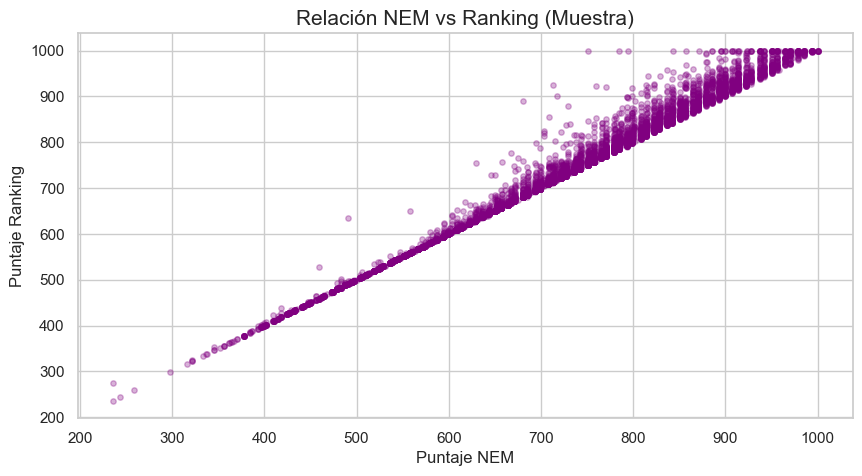

In [5]:
# 2. Scatter Plot: NEM vs Ranking
plt.figure(figsize=(10, 5))
sample = df_clean.sample(min(5000, len(df_clean)))
plt.scatter(sample['PTJE_NEM'], sample['PTJE_RANKING'], alpha=0.3, s=15, color='purple')
plt.title('Relación NEM vs Ranking (Muestra)', fontsize=15)
plt.xlabel('Puntaje NEM')
plt.ylabel('Puntaje Ranking')
plt.show()

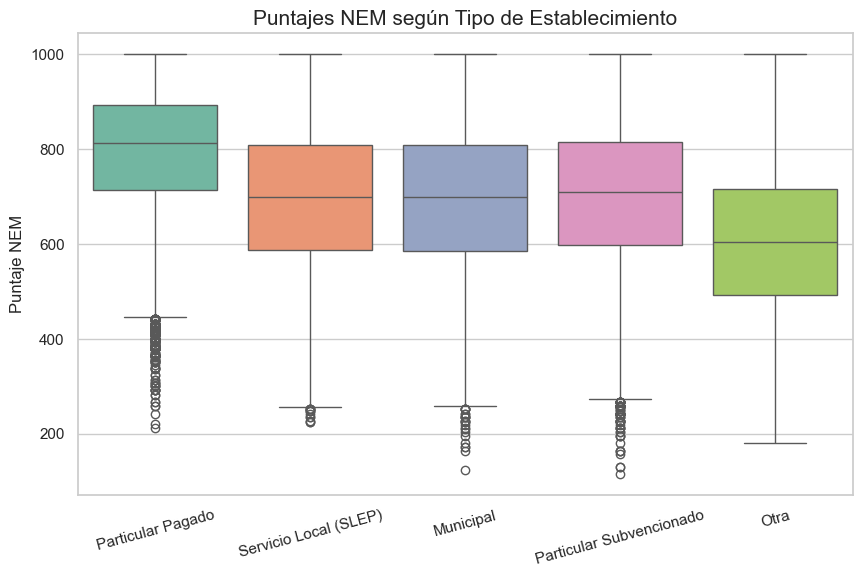

In [6]:
# 3. Boxplot: NEM por Dependencia
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='NOMBRE_DEPENDENCIA', y='PTJE_NEM', hue='NOMBRE_DEPENDENCIA', palette='Set2', legend=False)
plt.title('Puntajes NEM según Tipo de Establecimiento', fontsize=15)
plt.xlabel('')
plt.ylabel('Puntaje NEM')
plt.xticks(rotation=15) # Inclina un poco los textos de abajo para que no choquen
plt.show()

In [ ]:
# 4. Estudiantes por Región
plt.figure(figsize=(10, 6))
reg_counts = df_clean['NOMBRE_REGION'].value_counts().reset_index()
reg_counts.columns = ['Región', 'Cantidad']
reg_counts = reg_counts[reg_counts['Región'] != 'Sin Registro']

sns.barplot(data=reg_counts, x='Cantidad', y='Región', hue='Región', palette='magma', legend=False)
plt.title('Cantidad de Estudiantes por Región', fontsize=15)
plt.xlabel('Cantidad')
plt.ylabel('')
plt.show()

In [ ]:
# 5. Barras: Dependencia
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='NOMBRE_DEPENDENCIA', hue='NOMBRE_DEPENDENCIA', palette='viridis', legend=False)
plt.title('Cantidad Total de Estudiantes por Dependencia', fontsize=15)
plt.xlabel('')
plt.ylabel('Cantidad')
plt.show()

In [ ]:
# 6. Violin Plot: Comparativa de Formas
plt.figure(figsize=(10, 5))
melted = df_clean[['PTJE_NEM', 'PTJE_RANKING']].melt(var_name='Tipo', value_name='Puntaje')
sns.violinplot(data=melted, x='Tipo', y='Puntaje', hue='Tipo', palette='muted', legend=False)
plt.title('Comparación de Curvas: NEM vs Ranking', fontsize=15)
plt.xlabel('')
plt.show()